In [1]:
import torch
torch.set_printoptions(precision=3, sci_mode=False)

%load_ext autoreload
%autoreload 2

### Training

In [2]:
from icl.utils.unified_interface import unified_train

task_name = "latent"
for k in range(-1, 14):
    results = unified_train(task_name, k=k)

### Posterior concentration: how fast is it?

In [ ]:
from icl.latent_markov.analysis.posterior import plot_latent_task_posterior
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=-1)
info = plot_latent_task_posterior(exp_name, n_plots=5, major_only=True, max_positions=30,)

### Additive Separability

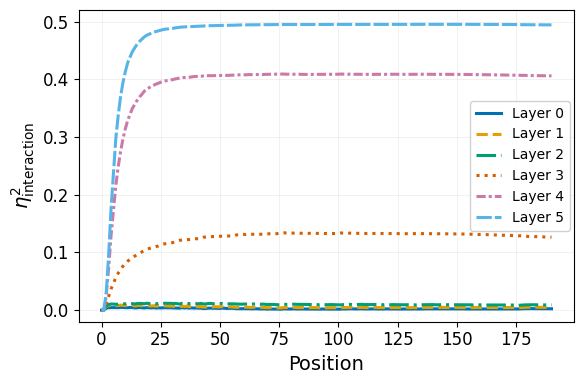

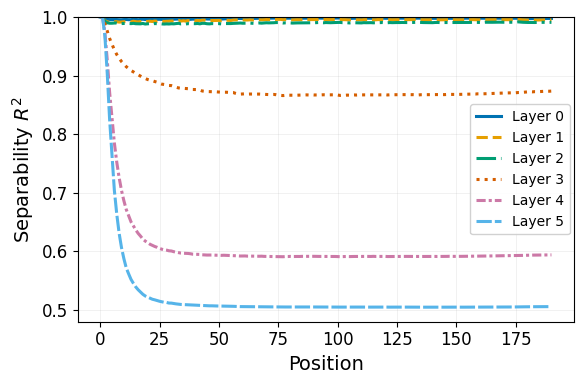

In [ ]:
from icl.latent_markov.analysis import plot_anova_separability_latent
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", -1)
results = plot_anova_separability_latent(
    exp_name, layers=range(6), 
    batch_size=1024, 
    log_x=False, 
    print_summary=False,
    show_ylabel=False,
    extraction_point="post_mlp",
    )

In [3]:
anova_results = results["anova_results"]
print("E3 (Latent Markov) — η²_interaction at final position")
print("-" * 55)
for layer in sorted(anova_results.keys()):
    pos_dict = anova_results[layer]
    final_pos = max(pos_dict.keys())
    eta2 = pos_dict[final_pos].eta2_interaction
    print(f"  Layer {layer:>2d}: η² = {eta2:.4f}  (pos={final_pos})")

E3 (Latent Markov) — η²_interaction at final position
-------------------------------------------------------
  Layer  0: η² = 0.0025  (pos=190)
  Layer  1: η² = 0.0050  (pos=190)
  Layer  2: η² = 0.0091  (pos=190)
  Layer  3: η² = 0.1265  (pos=190)
  Layer  4: η² = 0.4060  (pos=190)
  Layer  5: η² = 0.4943  (pos=190)


### General ANOVA

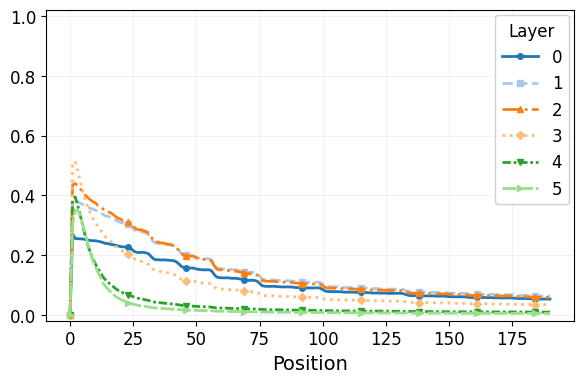

In [ ]:
from icl.latent_markov.analysis import plot_task_vector_r2_latent
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", -1)
results = plot_task_vector_r2_latent(
    exp_name, 
    layers=range(6), 
    batch_size=1024,
    print_summary=False,
    log_x=False,
    show_ylabel=False,
    extraction_point="post_mlp",
    )

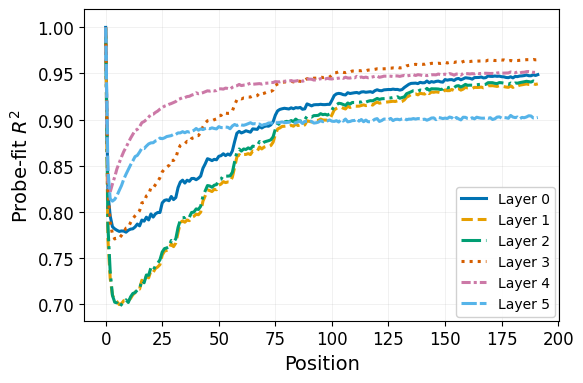

In [9]:
from icl.latent_markov.analysis import plot_probe_fit_r2_latent
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", -1)
results = plot_probe_fit_r2_latent(
    exp_name, 
    layers=range(6), 
    n_samples=4096, 
    batch_size=64, 
    include_logit=True,
    log_x=False,
    verbose=False,
    positions_of_interest=range(192),
    )

## Additive $R^2$ via token-conditioned (interventional) data

`plot_averaging_r2_latent` measures how well an additive ANOVA model
$$
  h_t \;=\; \mu_t \;+\; \sum_{k=1}^{K}\beta_{t,k}\,\theta_k
        \;+\; \nu_{s_t} \;+\; \varepsilon_t
$$
explains hidden-state variance, where $\theta_k$ are **task vectors**, $\nu_s$ are **token vectors**, $\mu_t$ is the position mean, and $\varepsilon_t$ is residual noise.

### Data collection (interventional)

For each evaluation position $t$ and each unique token value $a$, the function **fixes** the token at position $t$ to $a$ and runs a forward pass, collecting hidden states for every task.  This produces a tensor of shape
$(L,\;\lvert\mathcal{P}\rvert,\;V,\;K,\;B,\;D)$
where $V$ is the number of unique tokens, $K$ the number of tasks, and $B$ the batch size per cell.  Fixing the token **breaks the task–token confounding** that arises in natural sequences (where the token distribution depends on the task identity through the Markov dynamics).

### Estimation of $\theta_k$ and $\nu_s$ (ANOVA marginals)

At each estimation position $t$, cell means are computed by averaging over the $B$ batch samples:

$$
  \bar{h}_{t,k,a} \;=\; \frac{1}{B} \sum_{b=1}^{B} h_{t,k,a,b}.
$$

**Per-position demeaning.**  Before pooling across positions, the position mean $\mu_t$ is removed from each cell mean:

$$
  \mu_t = \frac{1}{K\,V} \sum_{k,a} \bar{h}_{t,k,a}, \qquad
  \tilde{h}_{t,k,a} = \bar{h}_{t,k,a} - \mu_t.
$$

This eliminates position-specific shifts (e.g.\ from rotary embeddings) before estimating task and token effects, and prevents bias when $V$ varies across positions.

The demeaned cell means are then pooled across estimation positions:

$$
  \tilde{h}_{k,a} = \frac{1}{|\mathcal{T}_{\mathrm{est}}|}
      \sum_{t \in \mathcal{T}_{\mathrm{est}}} \tilde{h}_{t,k,a}.
$$

Standard balanced-ANOVA marginals give

$$
  \theta_k = \tilde{h}_{k,\cdot} - \tilde{h}_{\cdot,\cdot}, \qquad
  \nu_a    = \tilde{h}_{\cdot,a} - \tilde{h}_{\cdot,\cdot},
$$

where $\tilde{h}_{k,\cdot}$ averages over tokens, $\tilde{h}_{\cdot,a}$ averages over tasks, and $\tilde{h}_{\cdot,\cdot}$ is the grand mean of the demeaned data (approximately zero).  Both sets of vectors are centred (sum to zero).

A separate **raw grand mean** (before demeaning) is retained for use when `per_position_mean=False`.

### $R^2$ evaluation (subtract-then-project)

At each evaluation position $t$:

1. **Centre** the data: $\tilde{h} = h - \mu_t$ (per-position mean) or $\tilde{h} = h - \bar{h}_{\cdot,\cdot}$ (global grand mean, when `per_position_mean=False`).
2. **Task-only $R^2$**: project $\tilde{h}$ onto the $(K{-}1)$-dimensional task subspace $\operatorname{span}(\theta_1,\dots,\theta_{K-1})$ (drop-one for identifiability) via the orthogonal projector $P_{\mathrm{task}}$:
$$
  R^2_{\mathrm{task}} = \frac{\|P_{\mathrm{task}}\,\tilde{h}\|^2}{\|\tilde{h}\|^2}.
$$
3. **Additive $R^2$** (`fit_token="anova"`): the model prescribes that $\nu_{s_t}$ enters with coefficient 1 (a deterministic lookup, not a free parameter).  We therefore **subtract** the known token effect and then project onto the task subspace:
$$
  R^2_{\mathrm{additive}} = 1 - \frac{\|(I - P_{\mathrm{task}})(\tilde{h} - \nu_{s_t})\|^2}{\|\tilde{h}\|^2}.
$$
If the model is correct, removing $\nu_{s_t}$ eliminates the token-induced variance from the residual, so $R^2_{\mathrm{additive}} \ge R^2_{\mathrm{task}}$ in expectation.  When `fit_token="none"`, the token effect is not removed and $R^2_{\mathrm{additive}} = R^2_{\mathrm{task}}$.

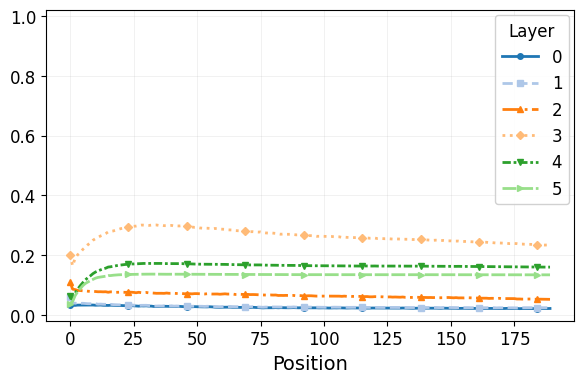

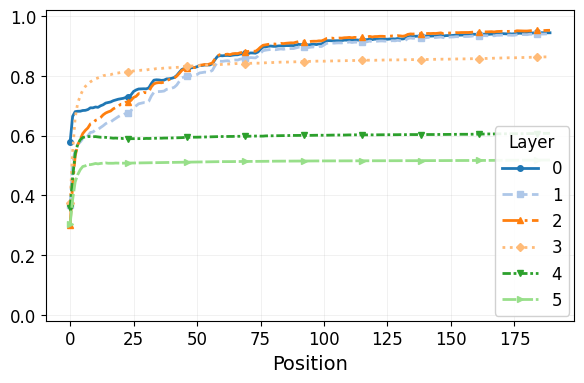

In [2]:
from icl.latent_markov.analysis import plot_averaging_r2_latent
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", -1)
result = plot_averaging_r2_latent(
    exp_name, layers=range(6), 
    estimation_positions=list(range(170, 190)),  # last 10 positions for task vec estimation
    evaluation_positions=range(190),
    fit_token="anova",
    batch_size=256, 
    per_position_mean=True,
    per_position_token_vecs=False,
    post_layernorm=True,
    log_x=False,
    show_ylabel=False,
    extraction_point="post_mlp",
    )

In [6]:
import numpy as np
for layer, pos_dict in result["results"].items():
    r2s = [v.r2_additive for pos, v in pos_dict.items() if pos >= 100]
    print(f"Layer {layer}: mean R² (t≥100) = {np.mean(r2s):.4f}")

Layer 0: mean R² (t≥100) = 0.9317
Layer 1: mean R² (t≥100) = 0.9259
Layer 2: mean R² (t≥100) = 0.9400
Layer 3: mean R² (t≥100) = 0.8558
Layer 4: mean R² (t≥100) = 0.6039
Layer 5: mean R² (t≥100) = 0.5162


### Decomposition of Hidden Representation

2026-03-23 21:56:50 - icl.latent_markov.analysis.probes - INFO - [sweep] collecting data for 6 layers (ep='post_mlp') ...
2026-03-23 21:56:58 - icl.latent_markov.analysis.probes - INFO - [sweep] fitting layer 0 (ep='post_mlp') ...
2026-03-23 21:57:14 - icl.latent_markov.analysis.probes - INFO - [sweep] fitting layer 1 (ep='post_mlp') ...
2026-03-23 21:57:33 - icl.latent_markov.analysis.probes - INFO - [sweep] fitting layer 2 (ep='post_mlp') ...
2026-03-23 21:57:54 - icl.latent_markov.analysis.probes - INFO - [sweep] fitting layer 3 (ep='post_mlp') ...
2026-03-23 21:58:13 - icl.latent_markov.analysis.probes - INFO - [sweep] fitting layer 4 (ep='post_mlp') ...
2026-03-23 21:58:29 - icl.latent_markov.analysis.probes - INFO - [sweep] fitting layer 5 (ep='post_mlp') ...

  Design Matrix Collinearity Summary (layer-independent)
  Condition number: 3.76e+01
  Features: task id=2  token=7  logit=8  (total=36)

  Group         dims        VIF  GVIF^(1/2p)   R² from rest
  ----------------------

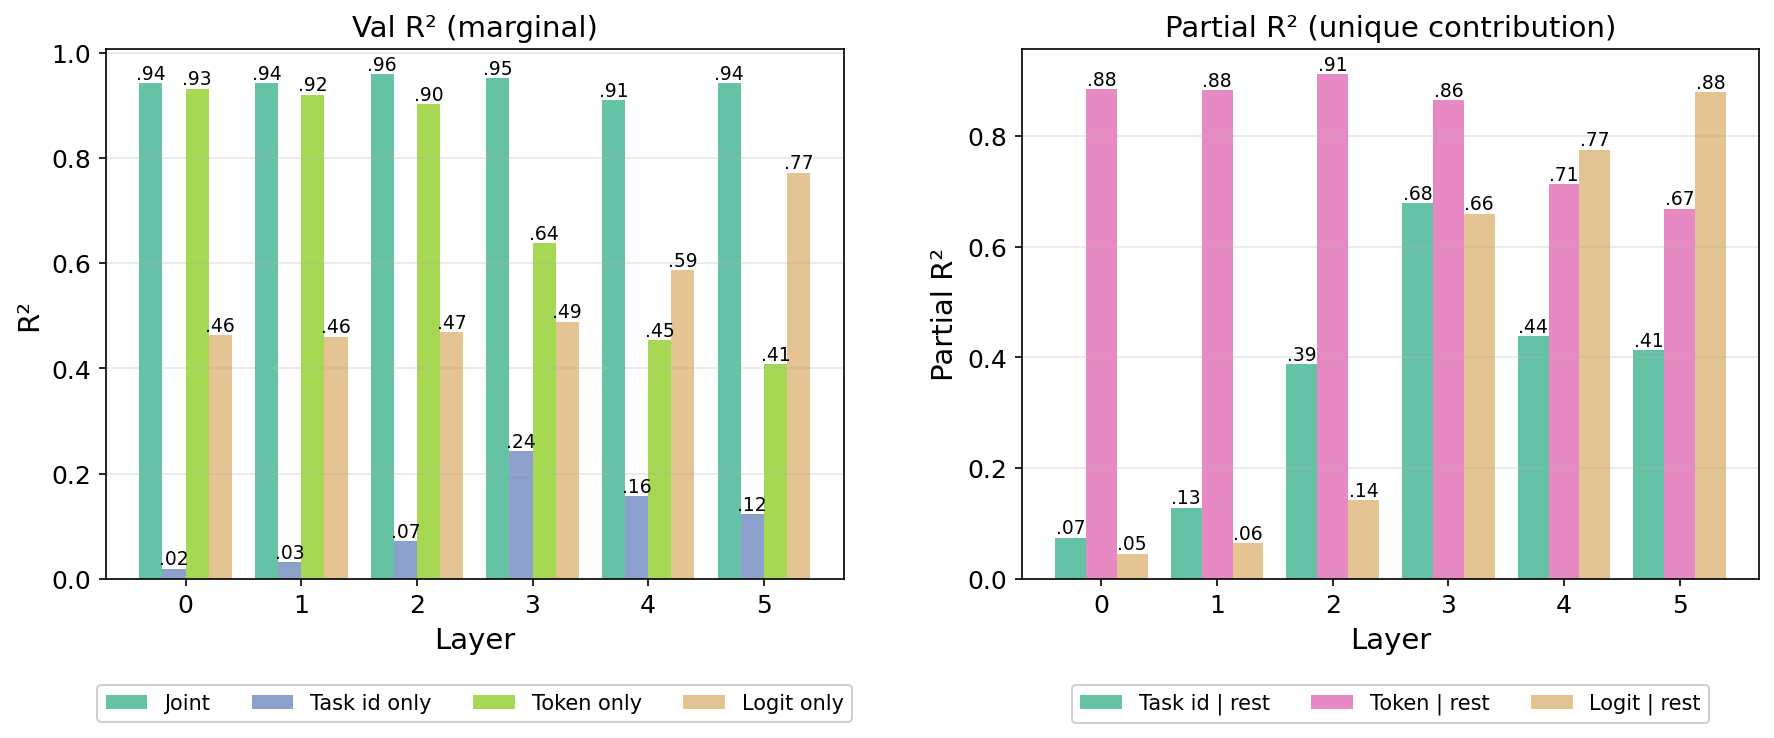

In [7]:
from icl.latent_markov.analysis import plot_val_r2_across_layers
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=-1)  # no minor tasks

fig, all_results = plot_val_r2_across_layers(
    exp_name,
    layers=range(6),
    B=64,
    n_samples=2**13,
    positions=range(170, 190),
    sample_mode="train",  # or "train", "minor"
    extraction_point="post_mlp",
    per_position_mean=False,
    use_task_identity=True,
)

### Posterior Alignment

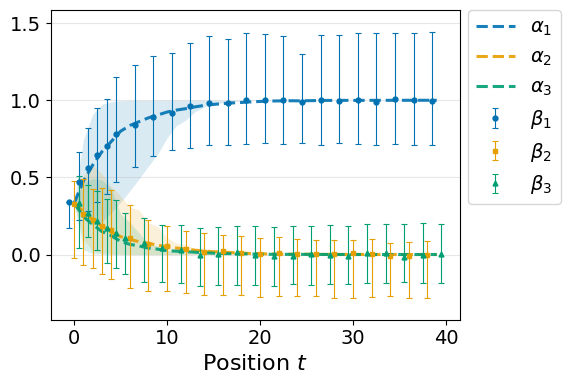

In [4]:
from icl.latent_markov.analysis import traj_averaging_projection_plot
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", -1)
result = traj_averaging_projection_plot(
    exp_name, 
    layer_index=5,
    task_ids=[0],
    estimation_positions=list(range(30, 40)),
    plot_positions=list(range(40)),
    per_position_mean=True,
    figsize=(6,4),
    show_legend=True,
    extraction_point="post_mlp",
    show_ylabel=False,
    beta_errbar="quantile",
    project_beta_simplex=False,
    B=1024,
    )

### Steering

2026-03-22 20:26:51 - icl.latent_markov.analysis.interventions.inject_posterior - INFO - [avg inj latent] rank=2, K=3, estimation_positions=range(25, 28)..39


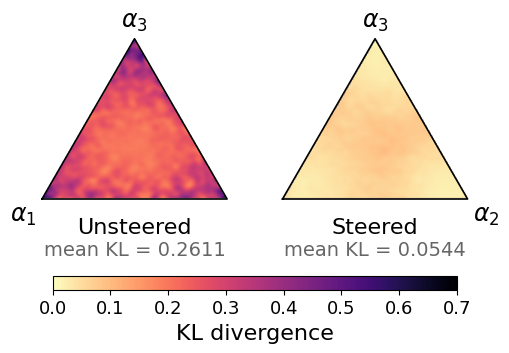

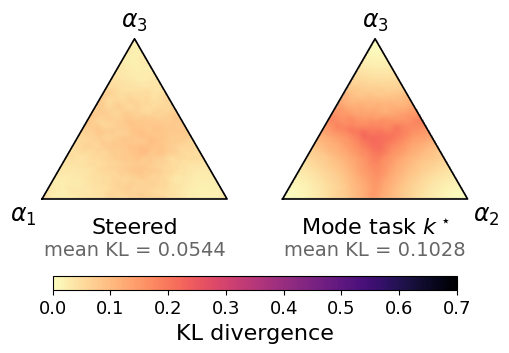


Averaging Injection  (latent, layer 3)
  rank=2  K=3  dirichlet_alpha=1.0
  Mean KL(baseline || q_α) = 0.2611
  Mean KL(injected || q_α) = 0.0544
  Mean KL(mode || q_α)     = 0.1028



In [1]:
from icl.latent_markov.analysis.interventions import intervene_averaging_injection
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=-1)
result = intervene_averaging_injection(
    exp_name=exp_name, 
    layer=3, 
    verbose=True,
    estimation_positions=range(25, 40),
    eval_positions=range(40),
    estimation_B=1024,
    per_position_mean=True,
    B=10_000,
    color_vmin=0, 
    color_vmax=0.7,
    extraction_point="post_mlp",
    )

### OOD vs ID Loss

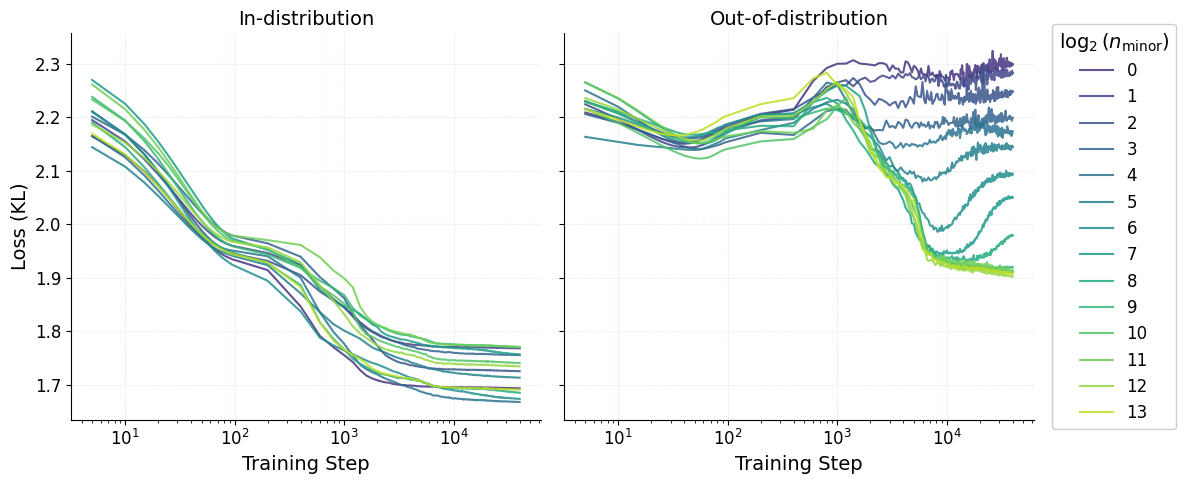

In [2]:
from icl.latent_markov.analysis import plot_id_ood_loss
out = plot_id_ood_loss(
    k_list=range(14),      # k where n_minor = 2**k (k=-1 means 0)
    logx=True,                 # log-scale x-axis
    figsize=(12, 5),
    show=True,
)

### Two inference modes

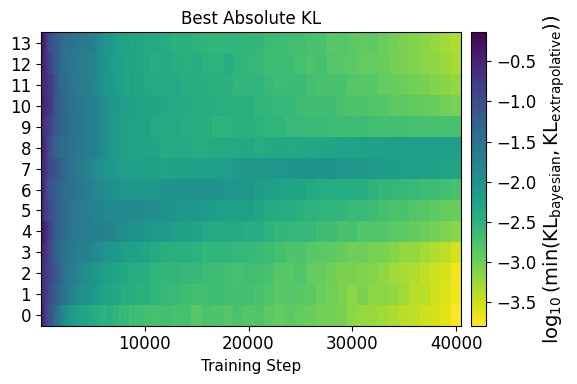

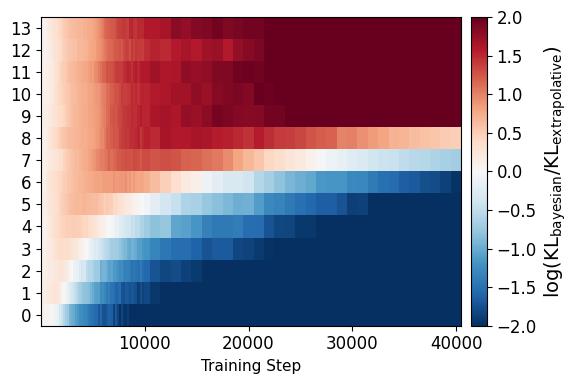

<Figure size 640x480 with 0 Axes>

In [2]:
from icl.latent_markov.analysis import plot_kl_model_vs_two_bayes_latent_transition_across_k
out = plot_kl_model_vs_two_bayes_latent_transition_across_k(
    k_values=range(14),
    mode="train",
    num_samples=1024,
    show_ylabel=False,
    show=True,
    figsize=(6,4),
)

### OOD Major projection $R^2$

2026-03-23 17:19:16 - icl.utils.unified_ood_analysis - INFO - [process_ood_minor_metric] train_6bd015b01c9a6106a3b374da38f96f74: skipping 320 requested steps not found on disk (e.g. [0, 300, 500]...). Pass steps that match available checkpoints to suppress this.
2026-03-23 17:20:51 - icl.utils.unified_ood_analysis - INFO - [process_ood_minor_metric] train_e0d69f204346ef0a9f3d93d26fa86276: skipping 320 requested steps not found on disk (e.g. [0, 300, 500]...). Pass steps that match available checkpoints to suppress this.
2026-03-23 17:22:30 - icl.utils.unified_ood_analysis - INFO - [process_ood_minor_metric] train_27166489f1de34abb33a9684773a8199: skipping 320 requested steps not found on disk (e.g. [0, 300, 500]...). Pass steps that match available checkpoints to suppress this.
2026-03-23 17:24:28 - icl.utils.unified_ood_analysis - INFO - [process_ood_minor_metric] train_a06665fc4781172382478a4e44df9a47: skipping 320 requested steps not found on disk (e.g. [0, 300, 500]...). Pass steps

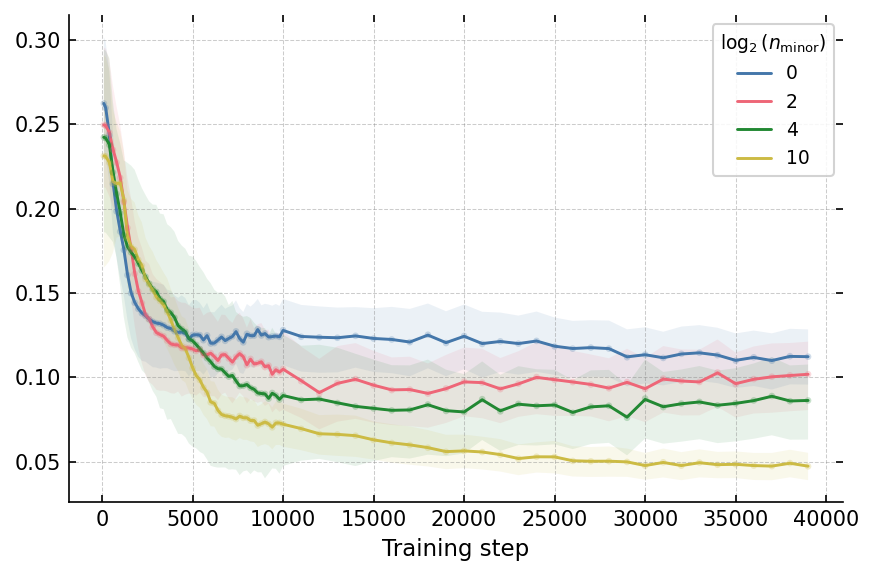

In [1]:
from icl.utils.ood_major_projection_r2 import plot_maj_r2_ood_across_steps_latent

out = plot_maj_r2_ood_across_steps_latent(
    k_list=[0,2,4,10],
    steps=list(range(0, 40_000, 100)),
    layer=3,
    n_gpus=2,
    ema_alpha=0.95,
    logx=False,
    show_title=False,
    n_ood=64,
    B=32,
    position_blocks=((0, -1),),
    figsize=(6,4),
    show_ylabel=False,
    extraction_point="post_mlp",
    force_recompute=True,
    band_alpha=0.1,
)

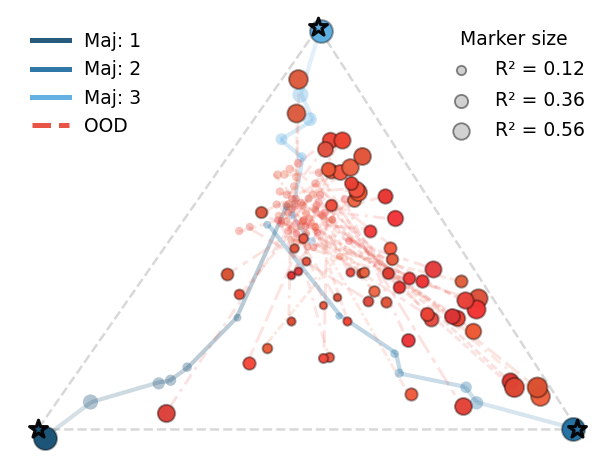

In [4]:
from icl.latent_markov.analysis import traj_posterior_projection_plot
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=-1)

out = traj_posterior_projection_plot(
    exp_name,
    layer_index=4,
    n_minor=0,
    n_ood=64,
    B=64,
    annotate=False,
    extraction_point="post_mlp",
    figsize=(4,3)
)
# out['fig'], out['ax']: figure and axes
# out['lambdas'], out['r2_scores']: projection coefficients and fit quality
# out['final_task_vecs'], out['task_vecs_over_all_time']: vectors and trajectories

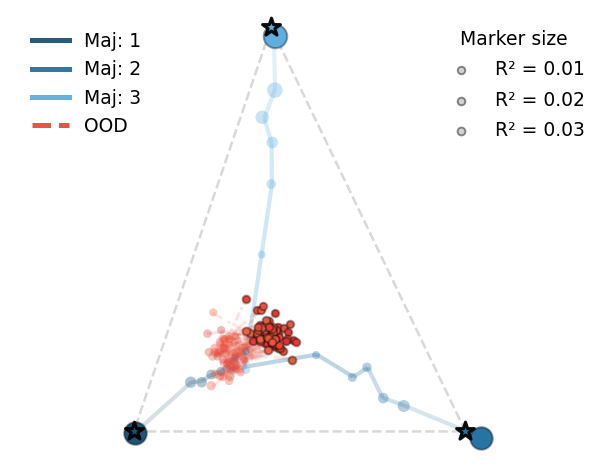

In [3]:
from icl.latent_markov.analysis import traj_posterior_projection_plot
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=10)

out = traj_posterior_projection_plot(
    exp_name,
    layer_index=4,
    n_minor=0,
    n_ood=64,
    B=64,
    annotate=False,
    extraction_point="post_mlp",
    figsize=(4,3)
)
# out['fig'], out['ax']: figure and axes
# out['lambdas'], out['r2_scores']: projection coefficients and fit quality
# out['final_task_vecs'], out['task_vecs_over_all_time']: vectors and trajectories

2026-03-25 14:50:03 - icl.latent_markov.analysis.directions - INFO - [attn-probes] computing scores for mode=major ...
2026-03-25 14:50:04 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 1/8 done
2026-03-25 14:50:05 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 2/8 done
2026-03-25 14:50:06 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 3/8 done
2026-03-25 14:50:06 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 4/8 done
2026-03-25 14:50:07 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 5/8 done
2026-03-25 14:50:08 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 6/8 done
2026-03-25 14:50:09 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 7/8 done
2026-03-25 14:50:10 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 8/8 done
2026-03-2

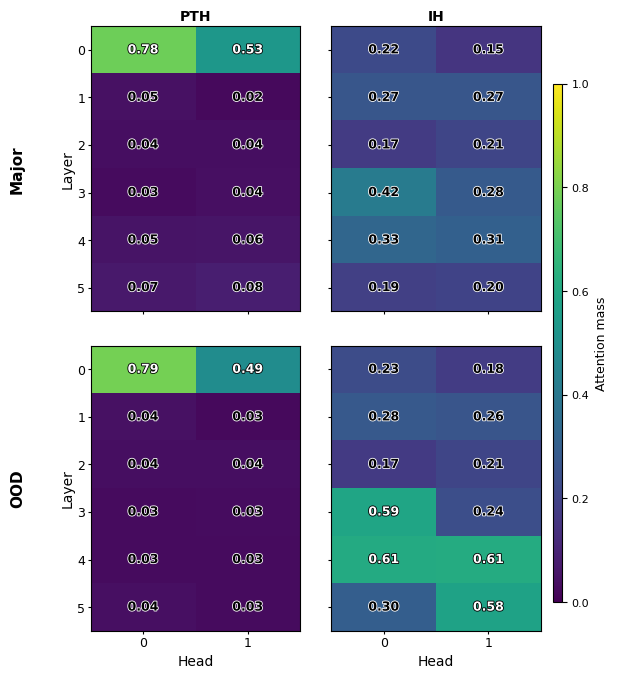

In [1]:
from icl.latent_markov.analysis.directions import get_attention_scores_nonpadded, plot_head_scores
from icl.utils.unified_interface import get_exp_name
from icl.latent_markov.analysis.ood import get_latent_sampler

exp_name = get_exp_name("latent", k=9)

scores = get_attention_scores_nonpadded(
    exp_name, B=128, n_batches=8, modes=["major", "ood"],
)

sampler, _, _ = get_latent_sampler(exp_name, n_minor=0, n_ood=256)
fig = plot_head_scores(multi_mode_scores=scores, vocab_size=sampler.num_states)

2026-03-25 14:50:16 - icl.latent_markov.analysis.directions - INFO - [attn-probes] computing scores for mode=major ...
2026-03-25 14:50:17 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 1/8 done
2026-03-25 14:50:18 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 2/8 done
2026-03-25 14:50:19 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 3/8 done
2026-03-25 14:50:19 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 4/8 done
2026-03-25 14:50:20 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 5/8 done
2026-03-25 14:50:21 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 6/8 done
2026-03-25 14:50:22 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 7/8 done
2026-03-25 14:50:22 - icl.latent_markov.analysis.directions - INFO - [attn-probes] mode=major batch 8/8 done
2026-03-2

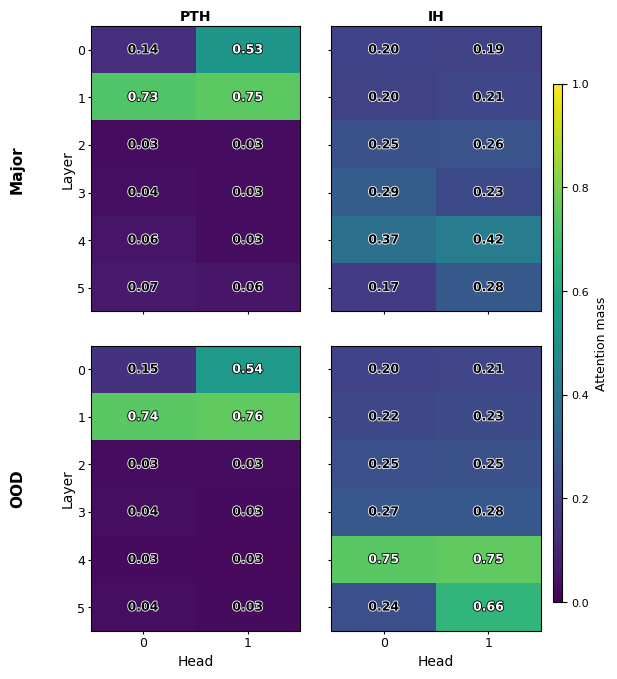

In [2]:
from icl.latent_markov.analysis.directions import get_attention_scores_nonpadded, plot_head_scores
from icl.utils.unified_interface import get_exp_name
from icl.latent_markov.analysis.ood import get_latent_sampler

exp_name = get_exp_name("latent", k=12)

scores = get_attention_scores_nonpadded(
    exp_name, B=128, n_batches=8, modes=["major", "ood"],
)

sampler, _, _ = get_latent_sampler(exp_name, n_minor=0, n_ood=1024)
fig = plot_head_scores(multi_mode_scores=scores, vocab_size=sampler.num_states)

2026-03-25 14:51:27 - icl.latent_markov.analysis.directions - INFO - [head-ablation] evaluating mode=major ...
2026-03-25 14:51:28 - icl.latent_markov.analysis.directions - INFO - [head-ablation] evaluating mode=minor ...
2026-03-25 14:51:30 - icl.latent_markov.analysis.directions - INFO - [head-ablation] evaluating mode=ood ...

-------------------------------------------------------------
  Head Ablation — Δ𝓛/g (% of ICL gain)  [CE nats]
-------------------------------------------------------------
Condition                       major       minor         ood
-------------------------------------------------------------
unablated                      1.7178      1.9023      1.9116
L4H0                           1.7178      1.9631      1.9631
L4H1                           1.7155      1.9727      1.9720
L4H0+L4H1                      1.7219      2.0500      2.0504
-------------------------------------------------------------
                                Δ/g %       Δ/g %       Δ/g 

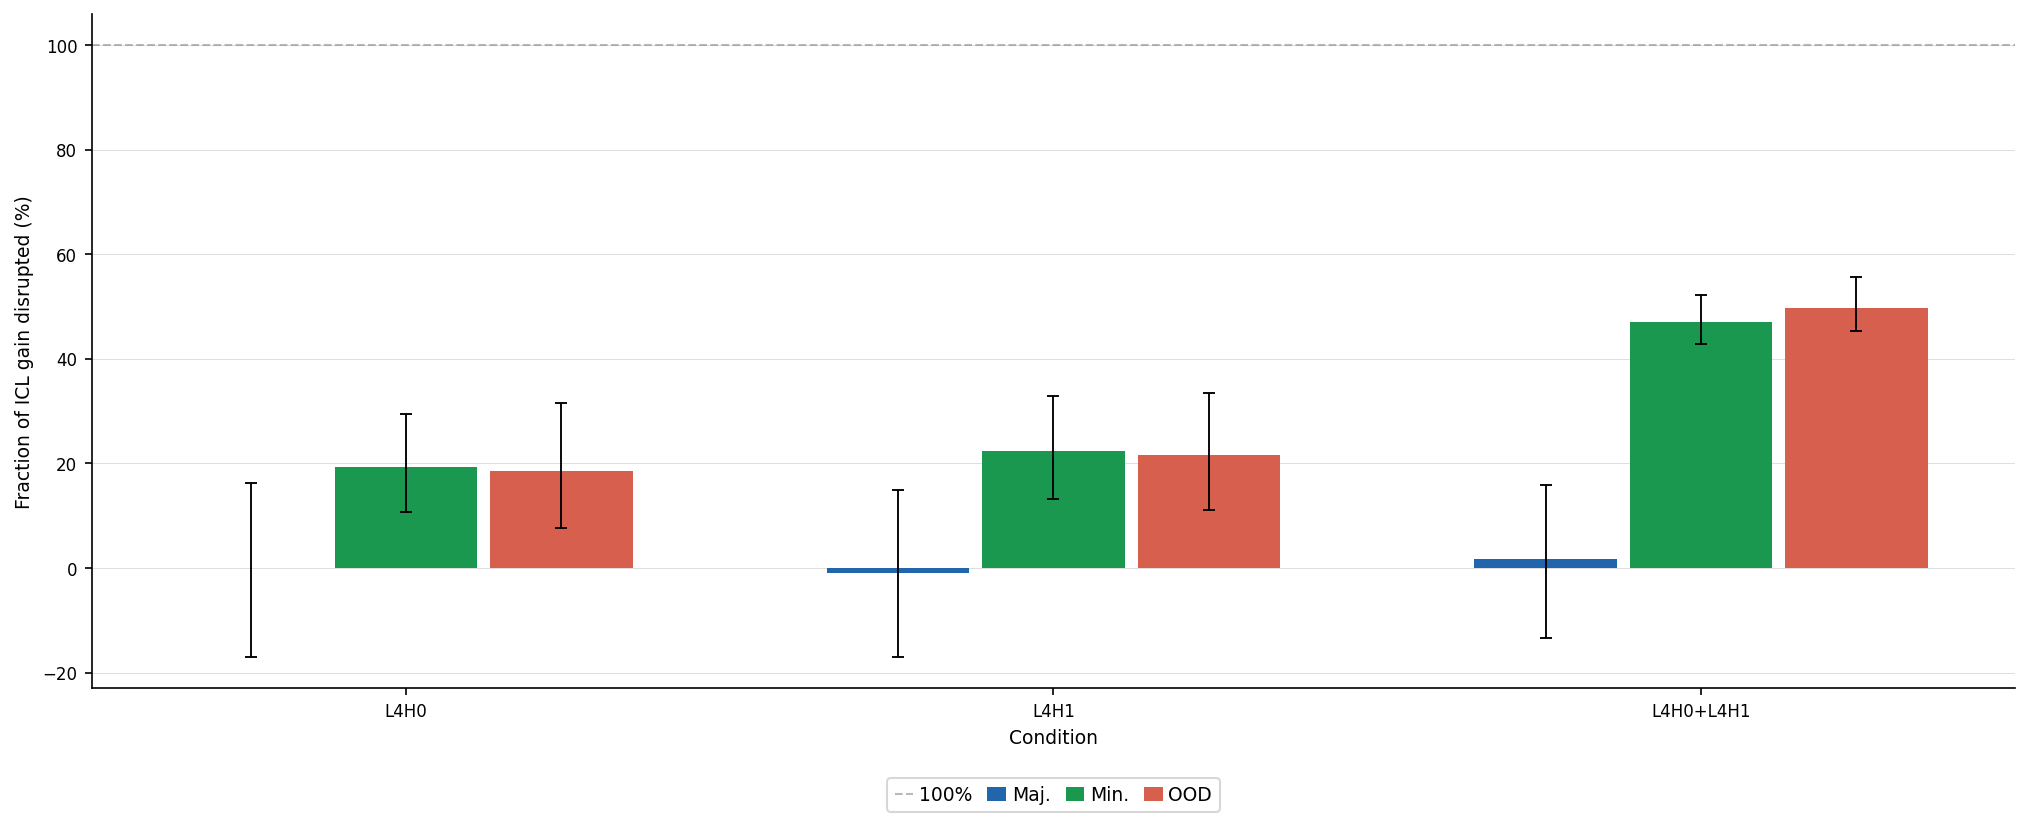

In [3]:
from icl.latent_markov.analysis.directions import head_ablation_experiment
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=12)

# Ablate L1H0 (strong IH, score=0.62) and L3H1 (moderate IH, score=0.45)
# Evaluates each head separately + both jointly, on major/minor/OOD samples
out = head_ablation_experiment(exp_name, ablations=[(4, 0), (4, 1)], B=128, n_batches=8)

2026-03-25 13:12:27 - icl.latent_markov.analysis.interventions.optimal_orth - INFO - [opt-dir] Phase 1: Collecting token-conditioned hiddens (ANOVA) ...
2026-03-25 13:13:07 - icl.latent_markov.analysis.interventions.optimal_orth - INFO - [opt-dir] Phase 2: Loading model & caching eval data ...
2026-03-25 13:13:08 - icl.latent_markov.analysis.interventions.optimal_orth - INFO - [opt-dir] Phase 3: Collecting hiddens + bigrams ...
2026-03-25 13:13:09 - icl.latent_markov.analysis.interventions.optimal_orth - INFO - [opt-dir] Layer 0 ...

  ── Feature partial R² (layer 0, target=Minor) ──
  Full model R² = 0.0433  |  Cond# = 3.1  |  Eff. rank = 13.75 / 3
  ──────────────────────────────────────────────────
  Feature                pR²     FWL pR²         VIF
  ──────────────────────────────────────────────────
  bigram_clr          0.0118      0.0123        1.00
  one_hot_x_t         0.0166      0.0166        1.00
  position            0.0137      0.0141        1.00
  ──────────────────────

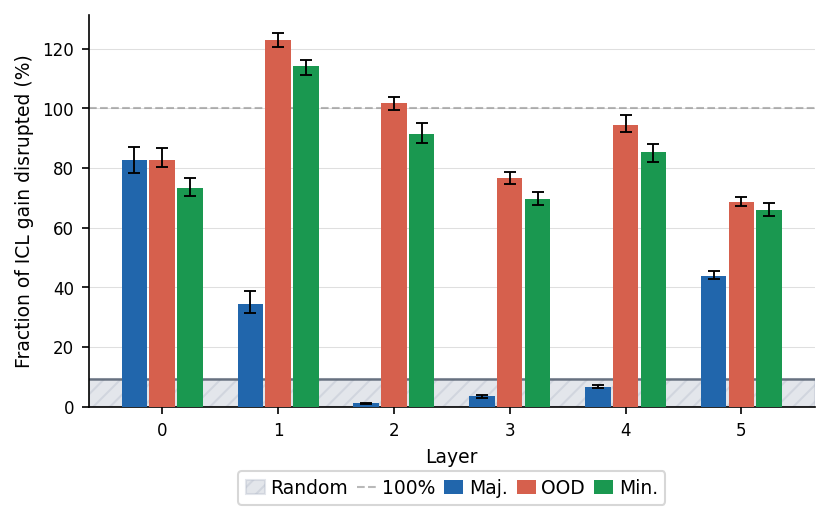


  V_opt Intervention — Δ𝓛/g (% of ICL gain)  [CE nats]
  ───────────────────────────────────────────────────────────────────────
  Layer    Maj.%     OOD%    Min.%   Rand.%  |    Maj.Δ    OOD Δ    Min.Δ
  ───────────────────────────────────────────────────────────────────────
      0     82.7%     82.5%     73.4%      0.3%  |   0.1802   0.2596   0.2423
      1     34.5%    122.8%    114.0%      1.0%  |   0.0752   0.3862   0.3766
      2      1.2%    101.7%     91.2%      2.0%  |   0.0026   0.3198   0.3013
      3      3.6%     76.6%     69.6%      5.8%  |   0.0077   0.2409   0.2297
      4      6.8%     94.4%     85.2%      2.7%  |   0.0147   0.2968   0.2815
      5     43.7%     68.7%     65.8%      1.9%  |   0.0953   0.2162   0.2173
  ───────────────────────────────────────────────────────────────────────
   Gain                                          |   0.2180   0.3146   0.3303

  ─────────────────────────────────────────────────────────
  Layer-averaged (mean ± std across 6 lay

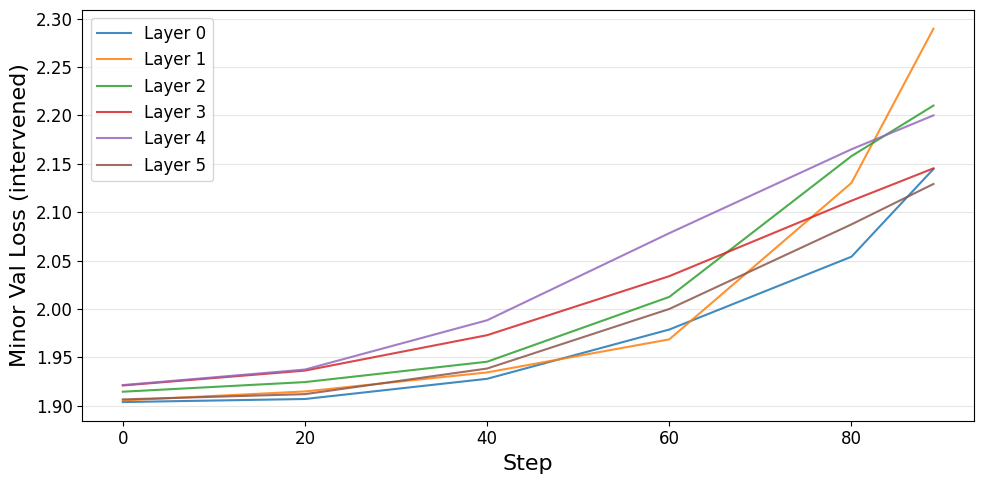

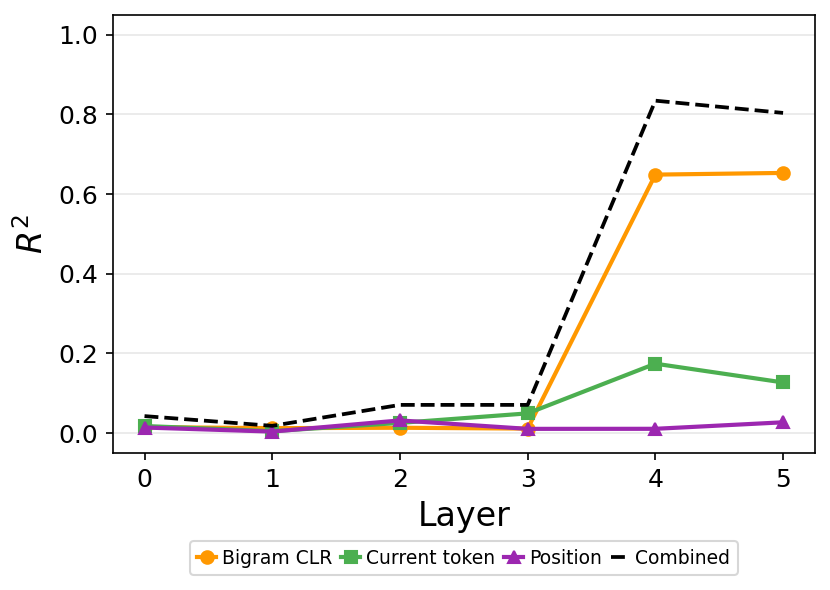

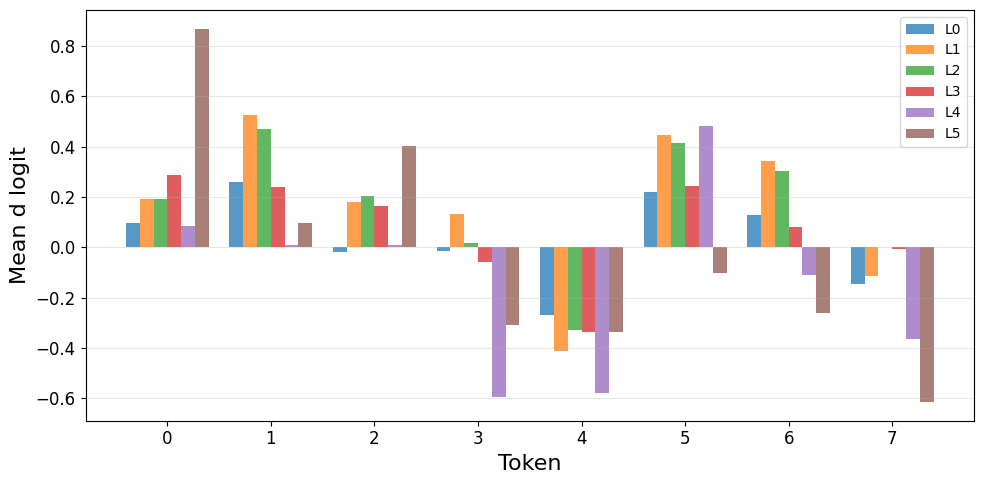

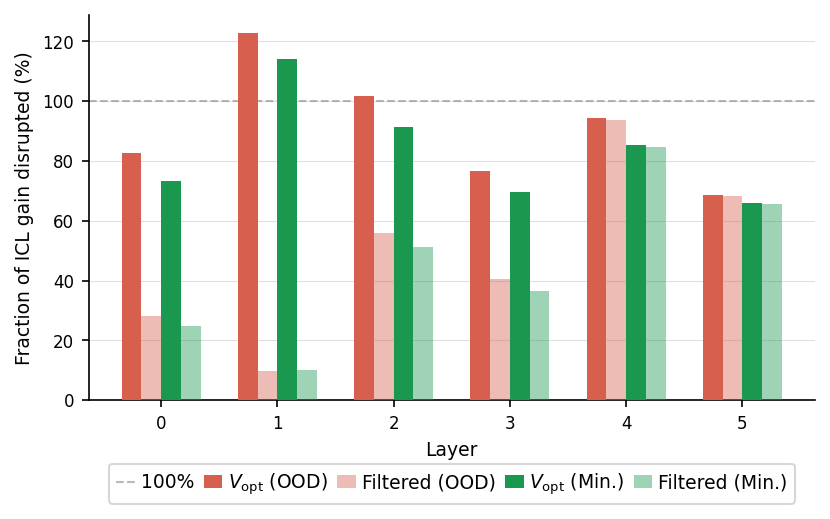


  V_opt & Enriched filter — Δ𝓛/g (% of ICL gain)  (feat: enriched)
  ───────────────────────────────────────────────────
  Layer  Vopt OOD%  Pred OOD%  Vopt Min.%  Pred Min.%
  ───────────────────────────────────────────────────
      0       82.5%       28.1%       73.4%       24.8%
      1      122.8%        9.9%      114.0%       10.0%
      2      101.7%       55.8%       91.2%       51.2%
      3       76.6%       40.4%       69.6%       36.6%
      4       94.4%       93.8%       85.2%       84.8%
      5       68.7%       68.4%       65.8%       65.5%
  ───────────────────────────────────────────────────



In [1]:
from icl.latent_markov.analysis import plot_optimal_orth_direction_across_layers
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=12)

all_results = plot_optimal_orth_direction_across_layers(
    exp_name=exp_name,
    layers=range(6),
    n_directions=6,
    n_opt_steps=90,
    opt_lr=0.01,
    opt_B=256,
    patience=50,
    grad_clip_norm=1.0,
    n_samples_eval=2**10,
    n_samples_probe=2**10,
    n_ood=2*10,
    scale=2.5,
    opt_target="minor",
    extraction_point="post_mlp",
    probe_method="averaging", 
    figsize=(6,4),
)

2026-03-25 16:09:51 - icl.latent_markov.analysis.interventions.remove_task - INFO - [remove-task sweep] ANOVA averaging for 6 layers ...
2026-03-25 16:10:23 - icl.latent_markov.analysis.interventions.remove_task - INFO - [remove-task sweep] computing baselines ...
2026-03-25 16:10:24 - icl.latent_markov.analysis.interventions.remove_task - INFO - [remove-task sweep] layer 0 ...
2026-03-25 16:10:24 - icl.latent_markov.analysis.interventions.remove_task - INFO - [remove-task sweep] layer 1 ...
2026-03-25 16:10:25 - icl.latent_markov.analysis.interventions.remove_task - INFO - [remove-task sweep] layer 2 ...
2026-03-25 16:10:26 - icl.latent_markov.analysis.interventions.remove_task - INFO - [remove-task sweep] layer 3 ...
2026-03-25 16:10:26 - icl.latent_markov.analysis.interventions.remove_task - INFO - [remove-task sweep] layer 4 ...
2026-03-25 16:10:27 - icl.latent_markov.analysis.interventions.remove_task - INFO - [remove-task sweep] layer 5 ...


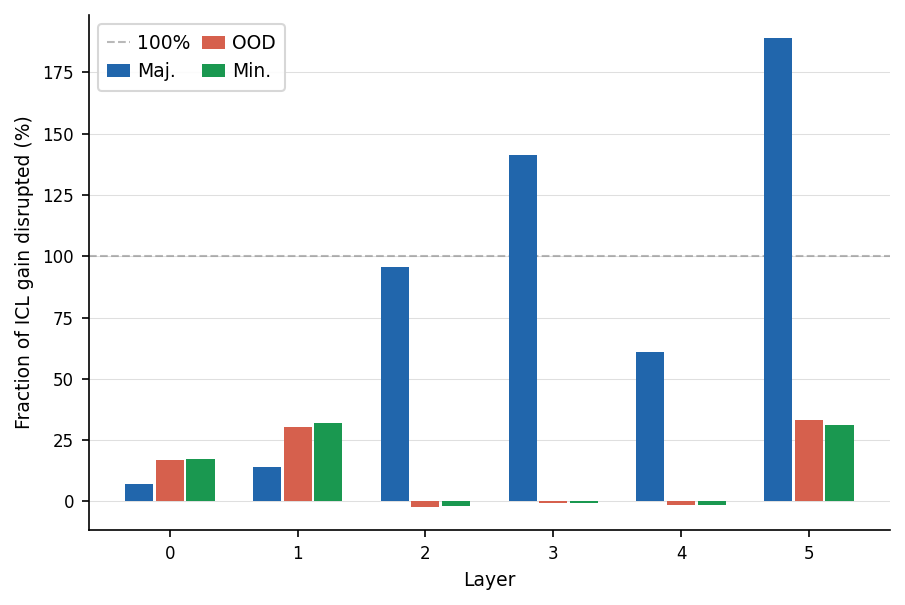


  Task Subspace Intervention — Δ𝓛/g (% of ICL gain)  [CE nats]
  ──────────────────────────────────────────────────────────────
  Layer    Maj.%     OOD%    Min.%  |    Maj.Δ    OOD Δ    Min.Δ
  ──────────────────────────────────────────────────────────────
      0      7.2%     16.8%     17.2%  |   0.0138   0.0512   0.0488
      1     14.2%     30.2%     32.0%  |   0.0273   0.0922   0.0908
      2     95.8%     -2.1%     -2.0%  |   0.1843  -0.0064  -0.0056
      3    141.2%     -0.7%     -0.4%  |   0.2717  -0.0022  -0.0013
      4     60.9%     -1.6%     -1.6%  |   0.1171  -0.0048  -0.0045
      5    188.8%     33.3%     31.3%  |   0.3633   0.1016   0.0885
  ──────────────────────────────────────────────────────────────
   Gain                                |   0.1924   0.3050   0.2832

  ─────────────────────────────────────────────────────────
  Layer-averaged (mean ± std across 6 layers) — CE nats
  ─────────────────────────────────────────────────────────
  Mode         Δ/g (%) 

In [1]:
from icl.latent_markov.analysis import plot_intervention_remove_task_across_layers
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=12)
fig, all_results = plot_intervention_remove_task_across_layers(
    exp_name=exp_name,              
    layers=range(6),      # or None for all layers
    B=64,
    n_samples_eval=512,
    n_ood=2**10,
    fit_n_samples=2048,
    #fit_positions=range(25),             # default late positions
    #eval_positions=list(range(5, 25)),            # default all positions
    #center_task_vecs=False,
    scale=2.5,
    figsize=(6, 4),
    show=True,
    save_path=None,
    extraction_point="post_mlp",
    probe_method="averaging",
)

2026-03-23 12:01:55 - icl.latent_markov.analysis.interventions.remove_task - INFO - [remove-task sweep] ANOVA averaging for 3 layers ...
2026-03-23 12:02:37 - icl.latent_markov.analysis.interventions.remove_task - INFO - [remove-task sweep] computing baselines ...
2026-03-23 12:02:37 - icl.latent_markov.analysis.interventions.remove_task - INFO - [remove-task sweep] layer 3 ...
2026-03-23 12:02:38 - icl.latent_markov.analysis.interventions.remove_task - INFO - [remove-task sweep] layer 4 ...
2026-03-23 12:02:39 - icl.latent_markov.analysis.interventions.remove_task - INFO - [remove-task sweep] layer 5 ...


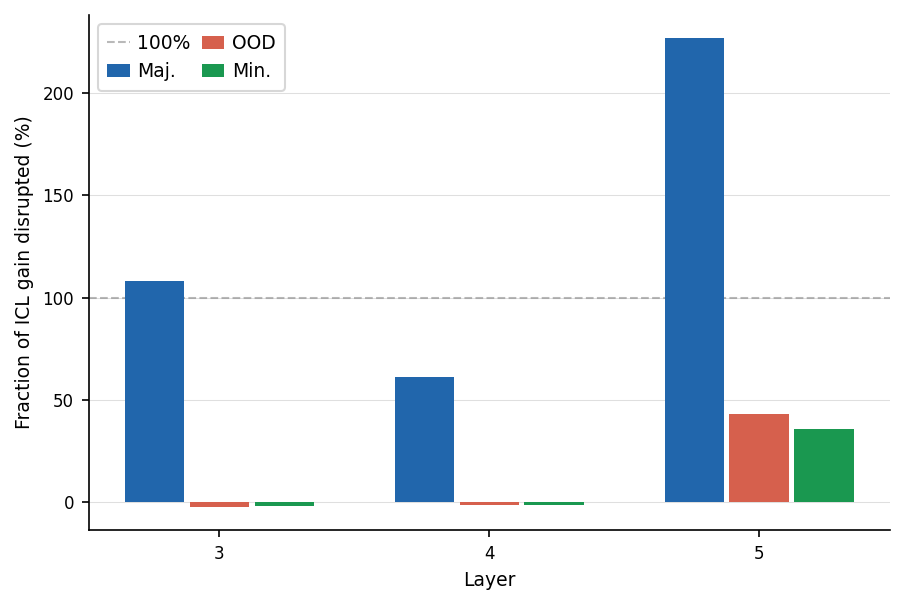


  Task Subspace Intervention — Δ𝓛/g (% of ICL gain)  [CE nats]
  ──────────────────────────────────────────────────────────────
  Layer    Maj.%     OOD%    Min.%  |    Maj.Δ    OOD Δ    Min.Δ
  ──────────────────────────────────────────────────────────────
      3    108.2%     -2.3%     -2.2%  |   0.2648  -0.0061  -0.0064
      4     61.0%     -1.6%     -1.5%  |   0.1493  -0.0042  -0.0044
      5    226.8%     43.1%     35.7%  |   0.5551   0.1147   0.1047
  ──────────────────────────────────────────────────────────────
   Gain                                |   0.2448   0.2659   0.2934

  ─────────────────────────────────────────────────────────
  Layer-averaged (mean ± std across 3 layers) — CE nats
  ─────────────────────────────────────────────────────────
  Mode         Δ/g (%)         Raw Δ   g (CE nats)
  ─────────────────────────────────────────────────────────
  Maj.      132.0±69.8        0.3231        0.2448
  OOD        13.1±21.2        0.0348        0.2659
  Min.       1

In [ ]:
from icl.latent_markov.analysis import plot_intervention_remove_task_across_layers
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=12)
fig, all_results = plot_intervention_remove_task_across_layers(
    exp_name=exp_name,              
    layers=range(3, 6),      # or None for all layers
    B=64,
    n_samples_eval=512,
    n_ood=2**10,
    fit_n_samples=2048,
    #fit_positions=range(25),             # default late positions
    #eval_positions=list(range(5, 25)),            # default all positions
    #center_task_vecs=False,
    scale=2.5,
    figsize=(6, 4),
    show=True,
    save_path=None,
    extraction_point="post_mlp",
    probe_method="averaging",
)

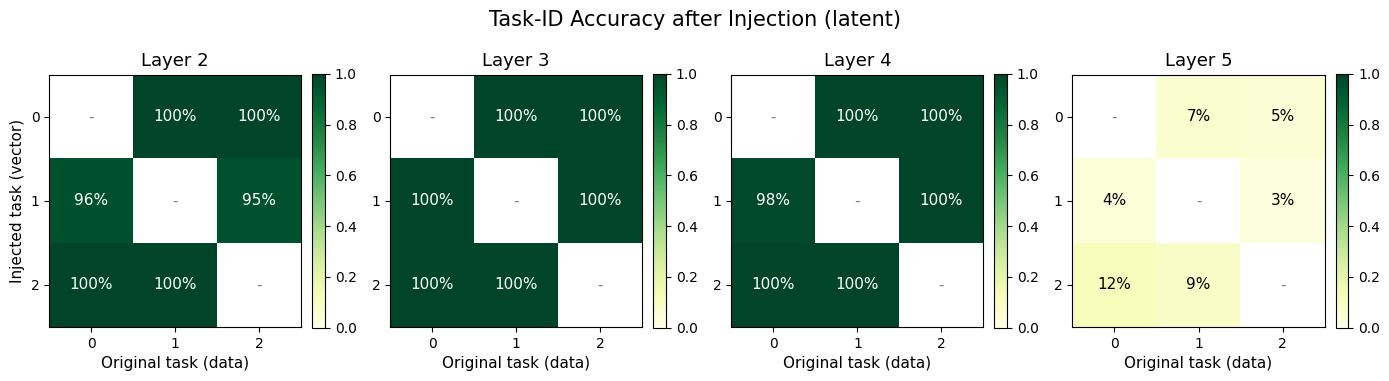

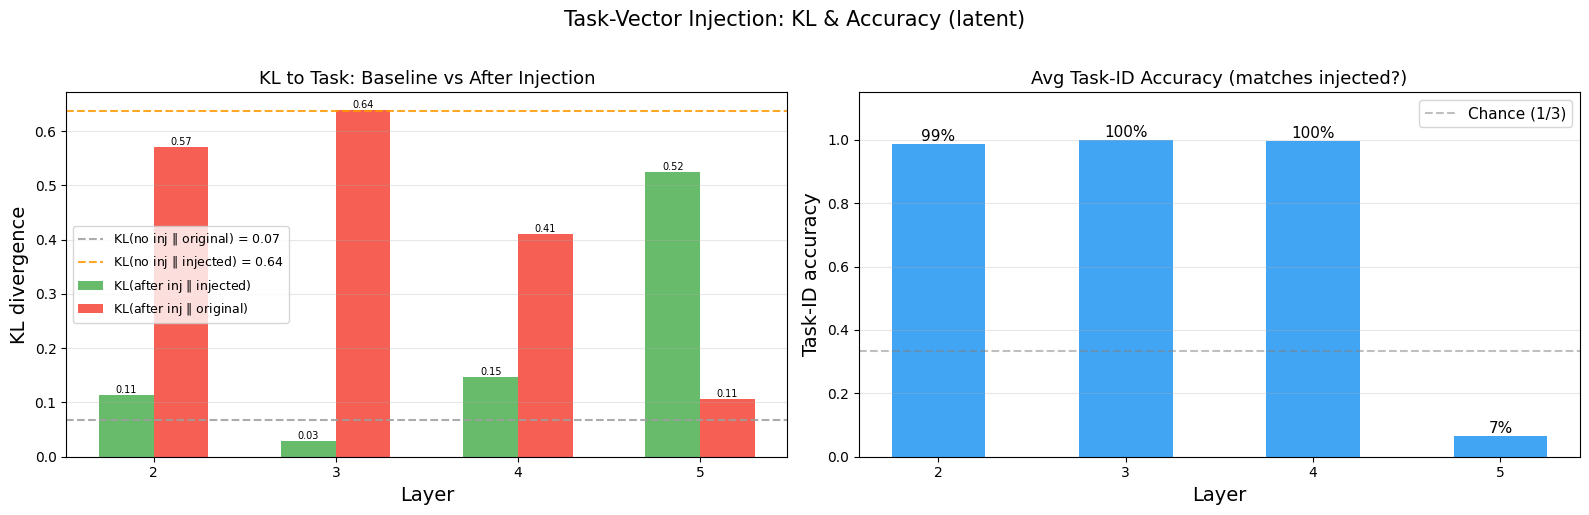

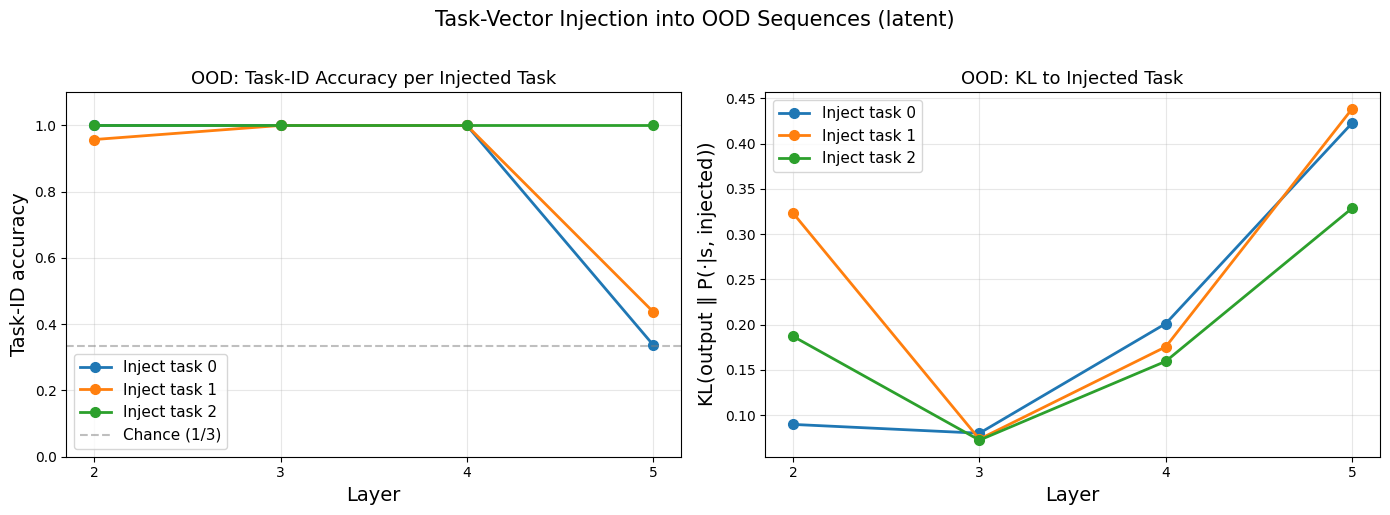

In [ ]:
from icl.latent_markov.analysis import plot_inject_task_vector_across_layers
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=11)

fig_hm, fig_kl, fig_ood, all_results = plot_inject_task_vector_across_layers(
    exp_name=exp_name,
    layers=[2, 3, 4, 5],   # or None for all layers
    B=64,
    n_samples_eval=1024,
    n_ood=64,
    fit_n_samples=2**13,
    fit_positions=range(25),           
    eval_positions=range(25),          # defaults to all positions
    center_task_vecs=True,
    scale=1.0,
    show=True,
    verbose=False,
)

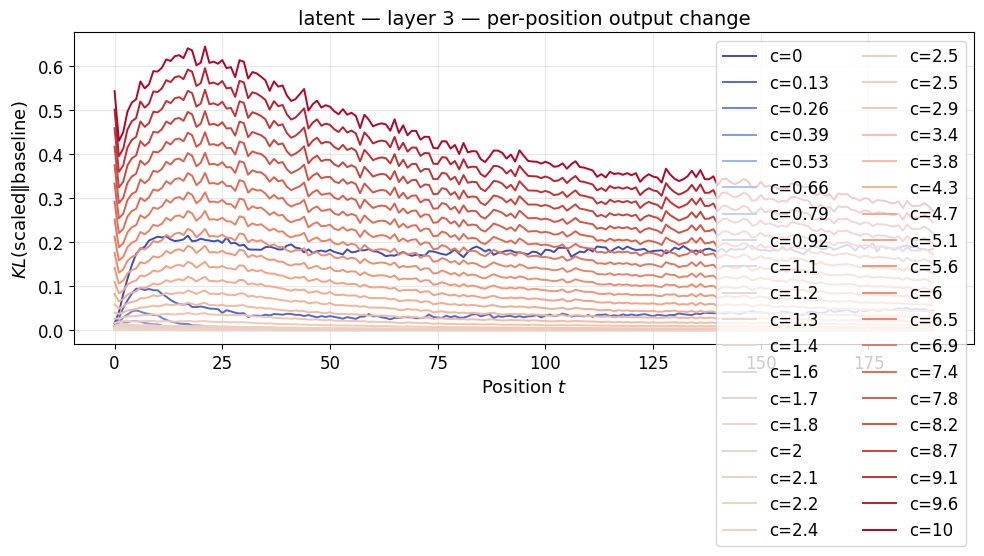

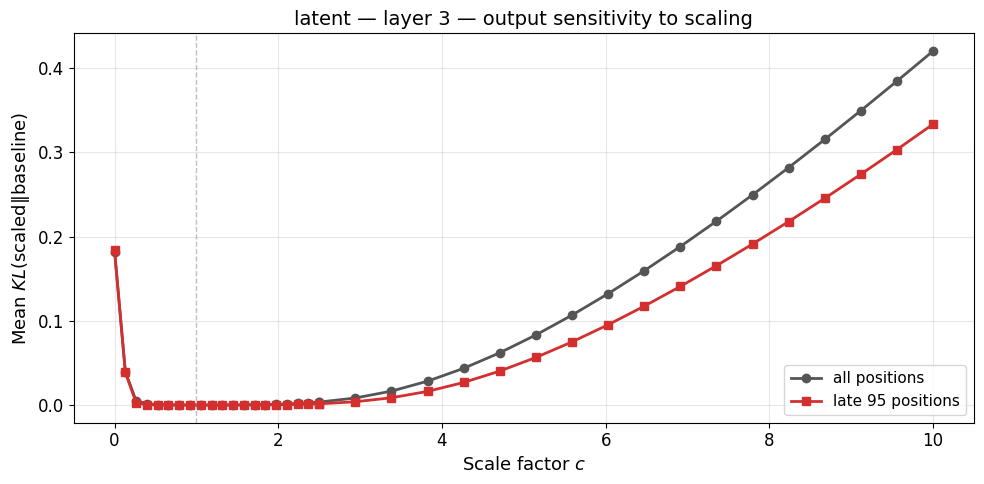

In [ ]:
import numpy as np
from icl.utils.unified_plot import intervene_scale_task_component
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", -1)

result = intervene_scale_task_component(
    "latent", exp_name,
    layer=3,
    scale_factors=np.concatenate([np.linspace(0, 2.5, 20), np.linspace(2.5, 10, 18)]).tolist(),
    B=64,
    n_samples=1000,
    estimation_B=128,
    per_position_mean=True,
    figsize=(10, 5),
)

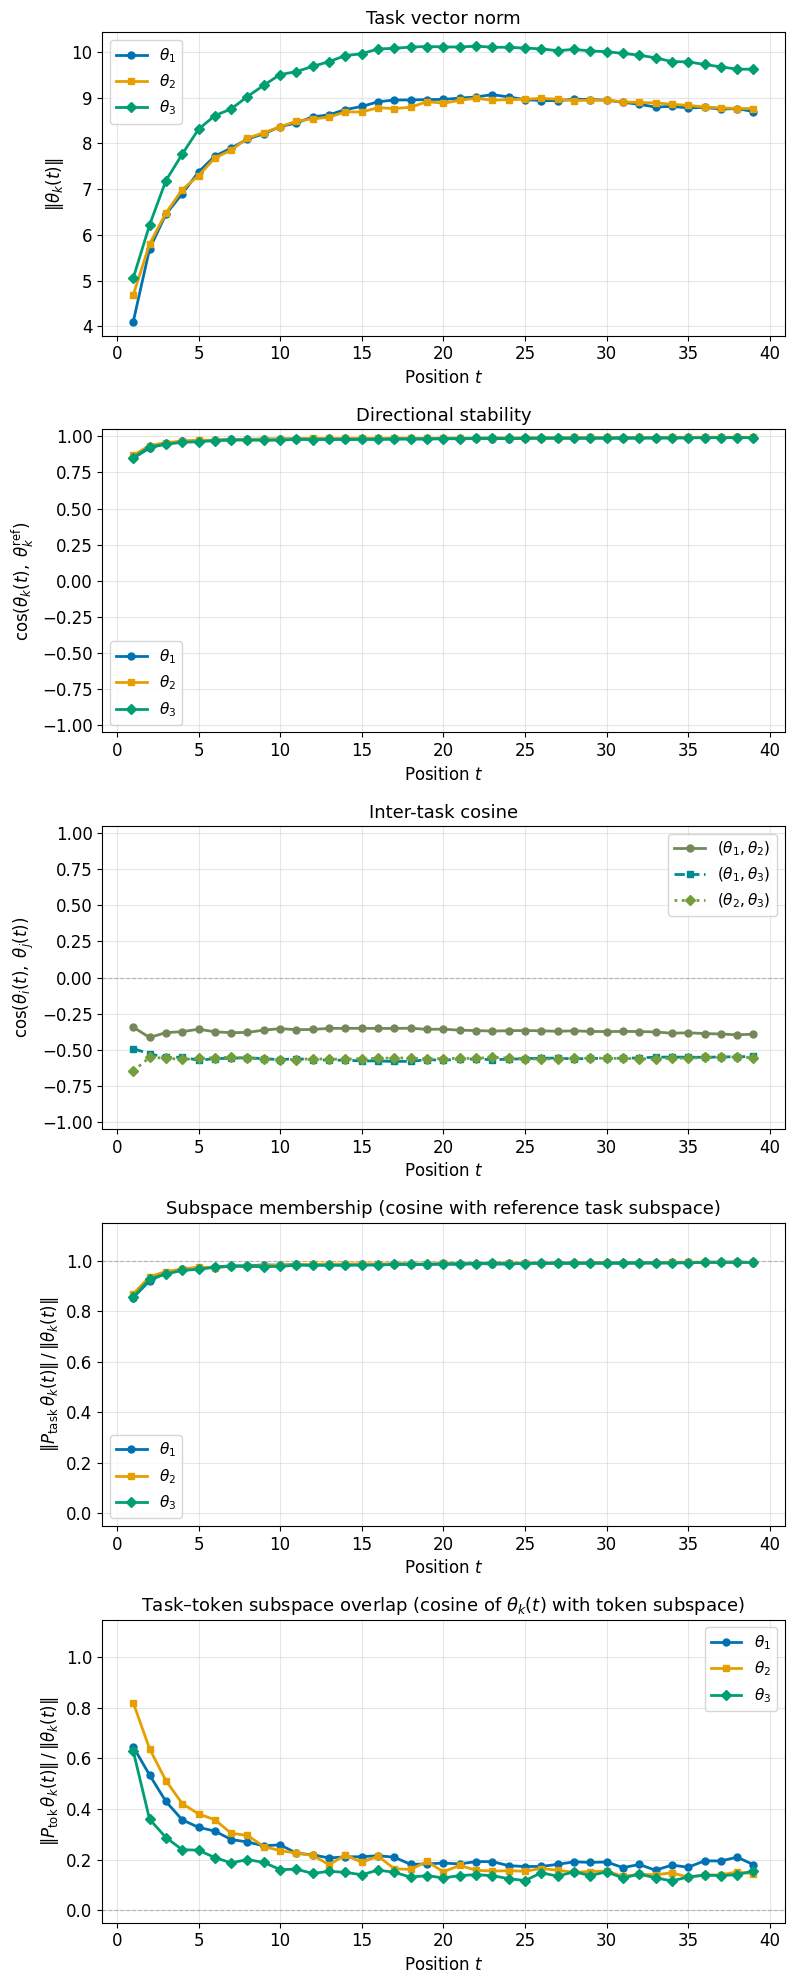

In [ ]:
from icl.utils.unified_plot import plot_task_vector_geometry
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", k=-1)
result = plot_task_vector_geometry("latent", exp_name, layer_index=3, B=1024, marker_every=1, plot_positions=range(1, 40))

## Residual Removal: Does projecting onto reference task+token subspace preserve model output?

Project each position's hidden state onto the **fixed reference subspace** (task vectors + token vectors estimated from late positions). If KL stays small even at early positions where R² is low, the residual is functionally unimportant.

[residual removal] layer=3, K=3, V=8, D=128
  reference subspace rank = 9 (task + token)
  estimation_positions = [25, 26, 27]..45


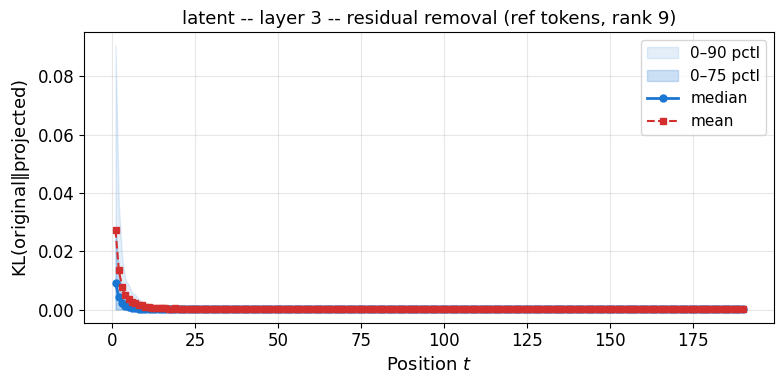


Residual Removal  (latent, layer 3)
  Token vectors: reference (pooled)
  Reference subspace rank = 9
  Overall mean KL(original, projected) = 0.000418
  Per-position mean KL range: [0.000029, 0.027322]



In [ ]:
from icl.utils.unified_plot import intervene_residual_removal
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", -1)

# Reference task vectors + reference (pooled) token vectors
result_ref = intervene_residual_removal(
    "latent", exp_name,
    layer=3,
    B=64,
    n_samples=2000,
    estimation_positions=list(range(25, 46)),
    estimation_B=128,
    per_position_mean=True,
    per_position_tokens=False,
    task_batch_size=8,
    marker_every=1,
    figsize=(8, 4),
    verbose=True,
)

[residual removal] layer=3, K=3, V=8, D=128
  per-position token vectors: rank range [9, 9]
  estimation_positions = [25, 26, 27]..45


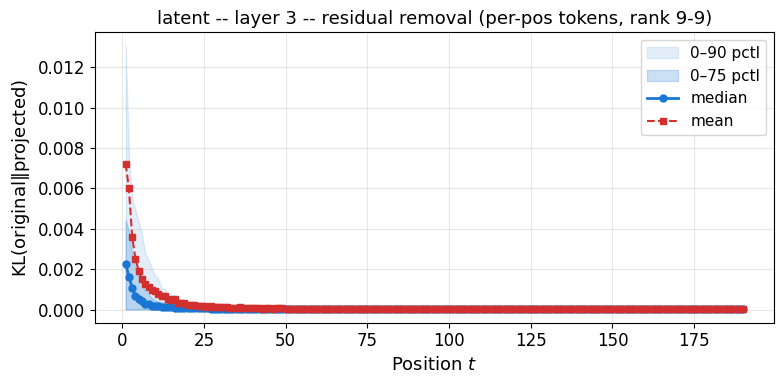


Residual Removal  (latent, layer 3)
  Token vectors: per-position
  Subspace rank range: [9, 9]
  Overall mean KL(original, projected) = 0.000201
  Per-position mean KL range: [0.000016, 0.007230]



In [ ]:

from icl.utils.unified_plot import intervene_residual_removal
from icl.utils.unified_interface import get_exp_name

exp_name = get_exp_name("latent", -1)

# Reference task vectors + per-position token vectors
result_ppt = intervene_residual_removal(
    "latent", exp_name,
    layer=3,
    B=64,
    n_samples=2000,
    estimation_positions=list(range(25, 46)),
    estimation_B=128,
    per_position_mean=True,
    per_position_tokens=True,
    task_batch_size=8,
    marker_every=1,
    figsize=(8, 4),
    verbose=True,
)